## LoRA

In [16]:
%matplotlib inline

import os
import sys
import math
import time
import json

from sys import platform
from pathlib import Path

sys.path.append('../../')

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from importlib.metadata import version 

import tiktoken

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

%load_ext autoreload
%autoreload 2

from llm_from_scratch.CH4.gpt import GPTModel, generate_text_simple
from llm_from_scratch.CH5.utils import load_weights_into_gpt, text_to_token_ids, token_ids_to_text
from llm_from_scratch.CH5.gpt_download import download_and_load_gpt2

from spam_dataset import SpamDataset, download_and_unzip_spam_data, create_balanced_dataset, random_split
from utils import calc_accuracy_loader, calc_loss_loader, calc_loss_batch, train_classifier, plot_values
from optim import create_optimizer, LayerDecayValueAssigner
from low_rank_adaptation import replace_linear_with_lora

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Prepare data

In [2]:
num_workers=0
batch_size=8
torch.manual_seed(123)

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
main_dirpath="/Users/reaungamornrat.sureerat/data/sms_spam_collection"
zip_path=f"{main_dirpath}/sms_spam_collection.zip"
extracted_path=main_dirpath
data_file_path=Path(extracted_path)/"SMSSpamCollection.tsv"
try: download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"Primary YRL failed: {e}. Trying backup URL....")
    url="https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


df=pd.read_csv(data_file_path, sep='\t', header=None, names=["Label", "Text"])
balanced_df=create_balanced_dataset(df)
# change the string class labels "ham" and "spam" into integer class labels 0 and 1
balanced_df["Label"]=balanced_df["Label"].map({"ham":0, "spam":1})
# split data into 70% training, 10% validation, and 20% testing
train_df, validation_df, test_df=random_split(balanced_df, 0.7, 0.1)
train_df.to_csv(f"{main_dirpath}/train.csv", index=None)
validation_df.to_csv(f"{main_dirpath}/validation.csv", index=None)
test_df.to_csv(f"{main_dirpath}/test.csv", index=None)

tokenizer=tiktoken.get_encoding("gpt2")
pad_token_id=tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]
print(f'{pad_token_id=}')
training_dataset=SpamDataset(csv_file=f"{main_dirpath}/train.csv", max_length=None, tokenizer=tokenizer, pad_token_id=pad_token_id)
print(f"{training_dataset.max_length=}")
# Note that this model can handles sequences up to 1024 tokens so we do not need to truncate the validation and test text to 
# `training_dataset.max_length` as long as the sequence lengths of the validation and test sets are < 1024 tokens.
val_dataset=SpamDataset(csv_file=f"{main_dirpath}/validation.csv", max_length=training_dataset.max_length, tokenizer=tokenizer,
                        pad_token_id=pad_token_id)
test_dataset=SpamDataset(csv_file=f"{main_dirpath}/test.csv", max_length=training_dataset.max_length, tokenizer=tokenizer,
                         pad_token_id=pad_token_id)

train_loader=DataLoader(dataset=training_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
val_loader=DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)
test_loader=DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)

/Users/reaungamornrat.sureerat/data/sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction
pad_token_id=50256
training_dataset.max_length=120


### Initializing model

In [3]:
CHOOSE_MODEL="gpt2-small (124M)"
INPUT_PROMPT="Every effort moves"
BASE_CONFIG={"vocab_size":50257,
             "context_length":1024,
             "drop_rate":0.,
             "qkv_bias":True}
model_configs={
    "gpt2-small (124M)":{"emb_dim":768, "n_layers":12, "n_heads":12},
    "gpt2-medium (355M)":{"emb_dim":1024, "n_layers":24, "n_heads":16},
    "gpt2-large (774M)":{"emb_dim":1280, "n_layers":36, "n_heads":20},
    "gpt2-xl (1558M)":{"emb_dim":1600, "n_layers":48, "n_heads":25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
assert training_dataset.max_length<=BASE_CONFIG["context_length"], (
    f"Dataset length {training_dataset.max_length} exceeds model's context"
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with max_length={BASE_CONFIG['context_length']}"
)

model_size=CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
print(f"{model_size=}")
model_dir='/Users/reaungamornrat.sureerat/data/GPT/GPT2'
settings, params=download_and_load_gpt2(model_size=model_size,models_dir=model_dir)
print(f'{os.listdir(model_dir)=}')

model=GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

model_size='124M'
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/GPT/GPT2/124M/checkpoint
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/GPT/GPT2/124M/encoder.json
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/GPT/GPT2/124M/hparams.json
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/GPT/GPT2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/GPT/GPT2/124M/model.ckpt.index
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/GPT/GPT2/124M/model.ckpt.meta
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/GPT/GPT2/124M/vocab.bpe
os.listdir(model_dir)=['124M']


In [4]:
# Test whether the model was loaded correctly
text_1="Every effort moves you"
token_ids=generate_text_simple(model=model,idx=text_to_token_ids(text_1, tokenizer), max_new_tokens=15, 
                               context_size=BASE_CONFIG['context_length'])
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [5]:
# replace the head
torch.manual_seed(123)
num_classes=2
model.out_head=torch.nn.Linear(in_features=BASE_CONFIG['emb_dim'], out_features=num_classes)
device=torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.mps.is_available() else torch.device('cpu')
model.to(device);

In [6]:
# calculate initial accuracy
train_accuracy=calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy=calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy=calc_accuracy_loader(test_loader, model, device, num_batches=10)
print(f"Train accuracy: {train_accuracy*100:.2f}%")
print(f"Val accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Train accuracy: 53.75%
Val accuracy: 45.00%
Test accuracy: 48.75%


In [7]:
# freeze the original model parameters and call `replace_linear_with_lora` to replace the `Linear` layer
total_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters before freezing: {total_params:,}")
for param in model.parameters(): param.requires_grad=False
total_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters after freezing: {total_params:,}")

replace_linear_with_lora(model, rank=16, alpha=16)
total_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable LoRA parameters: {total_params:,}")

Total trainable parameters before freezing: 124,441,346
Total trainable parameters after freezing: 0
Total trainable LoRA parameters: 2,666,528


In [8]:
model.to(device)
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (W_key): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (W_value): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (out_proj): LinearWithLoRA(
          (linear): Linear(in_features=768, out_features=768, bias=True)
          (lora): LoRALayer()
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): LinearWithLoRA(
            (linear): Linear(in_features=768, out_featu

In [14]:
# Since the B matrix in LoRA is 0, we expect the model performance to be the same as before
train_accuracy=calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy=calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy=calc_accuracy_loader(test_loader, model, device, num_batches=10)
print(f"Train accuracy: {train_accuracy*100:.2f}%")
print(f"Val accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Train accuracy: 52.50%
Val accuracy: 45.00%
Test accuracy: 48.75%


In [15]:
torch.manual_seed(123)
layer_decay=0.75
weight_decay=0.075
lr=1e-4

num_layers=model.get_num_layers()
print(f"Number of layers {num_layers}")
assigner=None
if layer_decay<1.:
    assigner=LayerDecayValueAssigner(values=[layer_decay**(num_layers+1-i) for i in range(num_layers+2)])
if assigner is not None: print(f"Assigned values: {assigner.values}")
skip_weight_decay_list=model.no_weight_decay()
print(f"{skip_weight_decay_list=}")
optimizer=create_optimizer(model=model, weight_decay=weight_decay, lr=lr, get_num_layer=assigner.get_layer_id if assigner is not None else None, 
                           get_layer_scale=assigner.get_scale if assigner is not None else None, 
                           filter_bias_and_bn=True, skip_list=skip_weight_decay_list)

# start training

start_time=time.time()

num_epochs=5
total_steps=len(train_loader)*num_epochs
train_losses, val_losses, train_accs, val_accs, example_seens, track_lrs=train_classifier(model, train_loader, val_loader, optimizer, 
                                                                               device, num_epochs=num_epochs, eval_freq=50, eval_iter=5,
                                                                               warmup_steps=int(0.2*total_steps), 
                                                                               initial_lr=3e-5, min_lr=1e-6)
end_time=time.time()
execution_time_minutes=(end_time-start_time)/60
print(f"Training completed in {execution_time_minutes:.2f} minutes")

Number of layers 12
Assigned values: [0.023757264018058777, 0.03167635202407837, 0.04223513603210449, 0.056313514709472656, 0.07508468627929688, 0.1001129150390625, 0.13348388671875, 0.177978515625, 0.2373046875, 0.31640625, 0.421875, 0.5625, 0.75, 1.0]
skip_weight_decay_list={'tok_emb', 'pos_emb'}
Param group {
  "layer_1_decay": {
    "weight_decay": 0.075,
    "params": [
      "trf_blocks.0.att.W_query.lora.A",
      "trf_blocks.0.att.W_query.lora.B",
      "trf_blocks.0.att.W_key.lora.A",
      "trf_blocks.0.att.W_key.lora.B",
      "trf_blocks.0.att.W_value.lora.A",
      "trf_blocks.0.att.W_value.lora.B",
      "trf_blocks.0.att.out_proj.lora.A",
      "trf_blocks.0.att.out_proj.lora.B",
      "trf_blocks.0.ff.layers.0.lora.A",
      "trf_blocks.0.ff.layers.0.lora.B",
      "trf_blocks.0.ff.layers.2.lora.A",
      "trf_blocks.0.ff.layers.2.lora.B"
    ],
    "lr_scale": 0.03167635202407837
  },
  "layer_2_decay": {
    "weight_decay": 0.075,
    "params": [
      "trf_blocks.1.a

650 650


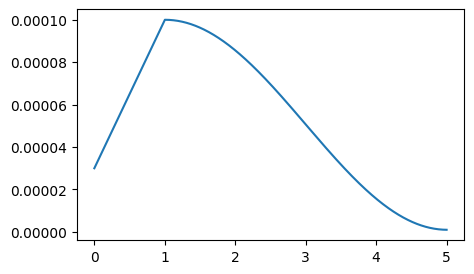

In [17]:
print(len(track_lrs), len(train_loader)*num_epochs)
epochs_tensor=torch.linspace(0, num_epochs, len(track_lrs))
fig, ax=plt.subplots(figsize=(5,3))
ax.plot(epochs_tensor, track_lrs)

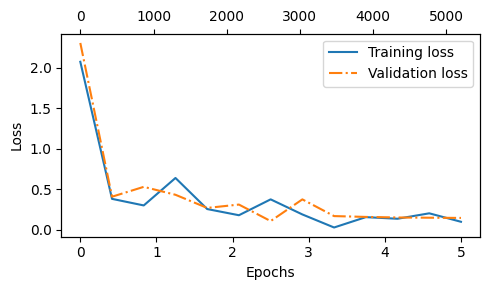

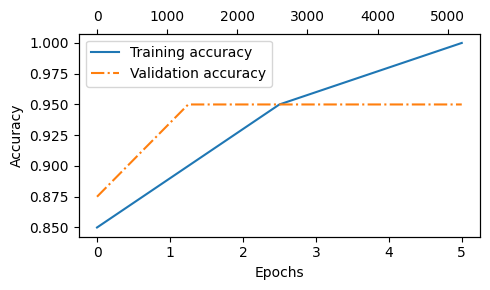

In [18]:
epochs_tensor=torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor=torch.linspace(0, example_seens, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

epochs_tensor=torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor=torch.linspace(0, example_seens, len(train_accs))
plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [19]:
train_accuracy=calc_accuracy_loader(train_loader, model, device)
val_accuracy=calc_accuracy_loader(val_loader, model, device)
test_accuracy=calc_accuracy_loader(test_loader, model, device)
print(f"Train accuracy: {train_accuracy*100:.2f}%")
print(f"Val accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Train accuracy: 97.50%
Val accuracy: 96.64%
Test accuracy: 95.33%
